# Used Car Price Prediction

# 1. Importing libabries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Loading Dataset and Analysis

In [2]:
df = pd.read_csv('dataset/Used_Car_Dataset.csv')

df.drop('Unnamed: 0', axis=1, inplace=True)

df.head()

,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0,63.75
1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0,8.99
2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0,23.75
3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0,13.56
4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0,24.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1553 entries, 0 to 1552
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   car_name            1553 non-null   object 
 1   registration_year   1553 non-null   object 
 2   insurance_validity  1553 non-null   object 
 3   fuel_type           1553 non-null   object 
 4   seats               1553 non-null   int64  
 5   kms_driven          1553 non-null   int64  
 6   ownsership          1553 non-null   object 
 7   transmission        1553 non-null   object 
 8   manufacturing_year  1553 non-null   object 
 9   mileage(kmpl)       1550 non-null   float64
 10  engine(cc)          1550 non-null   float64
 11  max_power(bhp)      1550 non-null   float64
 12  torque(Nm)          1549 non-null   float64
 13  price(in lakhs)     1553 non-null   float64
dtypes: float64(5), int64(2), object(7)
memory usage: 170.0+ KB


# 3. Visualzation of Dataset

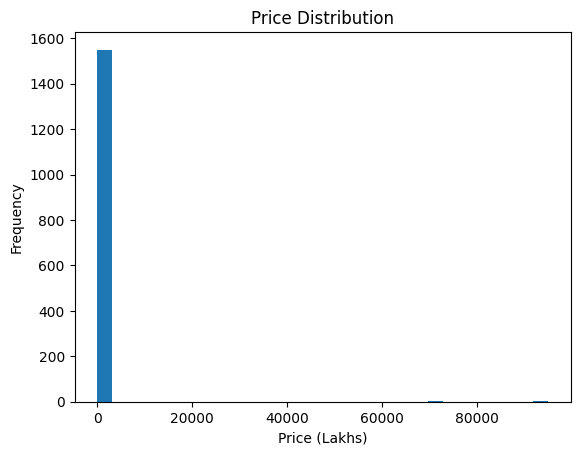

In [4]:
plt.figure()
plt.hist(df['price(in lakhs)'], bins=30)
plt.title('Price Distribution')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
plt.show()

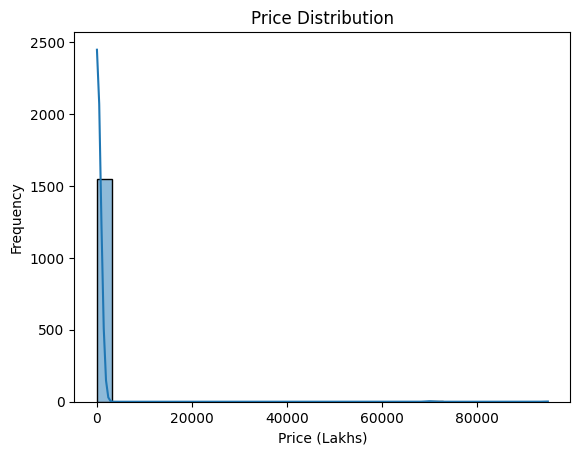

In [5]:
plt.figure()
sns.histplot(df['price(in lakhs)'], kde=True, bins=30)
plt.title('Price Distribution')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
plt.show()

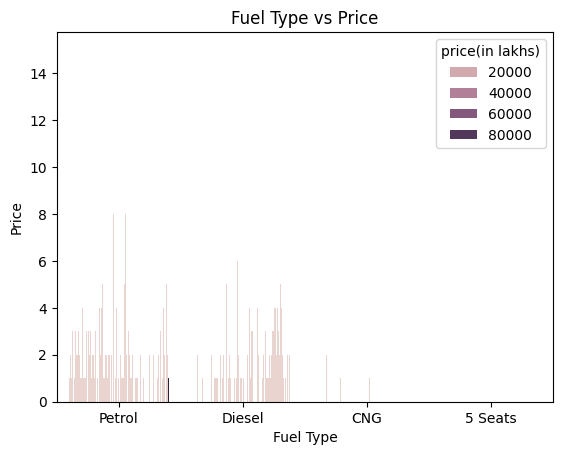

In [6]:
plt.figure()

sns.countplot(x='fuel_type', hue='price(in lakhs)', data=df)
plt.title('Fuel Type vs Price')
plt.xlabel('Fuel Type')
plt.ylabel('Price')

plt.show()

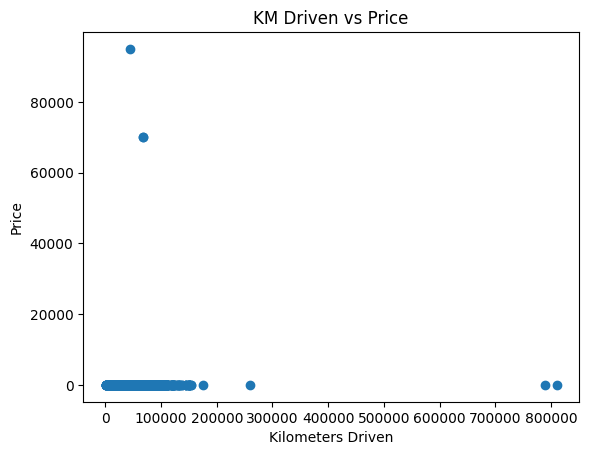

In [7]:
plt.figure()

plt.scatter(df['kms_driven'], df['price(in lakhs)'])
plt.title('KM Driven vs Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price')

plt.show()

# 4. Data Cleaning & Feature Engineering

In [8]:
# Age feature

# Step 1: Convert to numeric (invalid parsing → NaN)
df['manufacturing_year'] = pd.to_numeric(df['manufacturing_year'], errors='coerce')

# Step 2: Compute mode (most frequent year)
mode_year = df['manufacturing_year'].mode()[0]

# Step 3: Fill missing values with mode
df['manufacturing_year'].fillna(mode_year, inplace=True)

df['car_age'] = 2026 - df['manufacturing_year']

# Drop irrelevant columns
df = df.drop(['car_name'], axis=1, errors='ignore')

df = df.dropna()

/var/folders/s3/7_ps073573349p4rwxh_fxzr0000gn/T/ipykernel_55345/211302885.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['manufacturing_year'].fillna(mode_year, inplace=True)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1549 entries, 0 to 1552
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   registration_year   1549 non-null   object 
 1   insurance_validity  1549 non-null   object 
 2   fuel_type           1549 non-null   object 
 3   seats               1549 non-null   int64  
 4   kms_driven          1549 non-null   int64  
 5   ownsership          1549 non-null   object 
 6   transmission        1549 non-null   object 
 7   manufacturing_year  1549 non-null   float64
 8   mileage(kmpl)       1549 non-null   float64
 9   engine(cc)          1549 non-null   float64
 10  max_power(bhp)      1549 non-null   float64
 11  torque(Nm)          1549 non-null   float64
 12  price(in lakhs)     1549 non-null   float64
 13  car_age             1549 non-null   float64
dtypes: float64(7), int64(2), object(5)
memory usage: 181.5+ KB


# 5. Encoding and Scaling

In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# ---- One Hot Encoding ----
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# ---- Scaling ----
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

df = df_encoded

# 6. Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('price(in lakhs)', axis=1)
Y = df['price(in lakhs)']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1549 entries, 0 to 1552
Columns: 224 entries, seats to transmission_Power Windows Front
dtypes: bool(216), float64(8)
memory usage: 435.7 KB


# 7. Model Training

In [13]:
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, Y_train) 

Y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
print("R2 Score:", r2_score(Y_test, Y_pred))

MAE: 0.1422567357157103
RMSE: 1.5506202301966006
R2 Score: -0.0050259809779538145


In [14]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Evaluation

In [15]:


Y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
print("R2 Score:", r2_score(Y_test, Y_pred))


MAE: 0.08880530124632689
RMSE: 1.549453543834846
R2 Score: -0.0035141872206505553


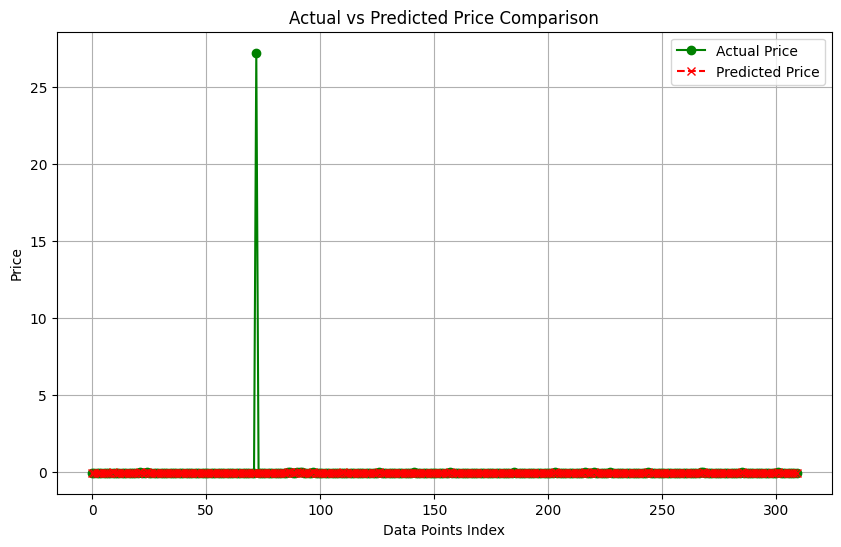

In [16]:
plt.figure(figsize=(10, 6))

# Convert to list if it's a pandas series (for safe indexing)
actual = list(Y_test)
predicted = list(Y_pred)

# Plot actual values (green)
plt.plot(actual, label='Actual Price', color='green', marker='o')

# Plot predicted values (red)
plt.plot(predicted, label='Predicted Price', color='red', linestyle='--', marker='x')

# Labels and title
plt.xlabel('Data Points Index')
plt.ylabel('Price')
plt.title('Actual vs Predicted Price Comparison')

# Legend and grid
plt.legend()
plt.grid(True)

plt.show()